
===== DLC REACH TRAJECTORY (first in-trial reaches) =====
DLC frames: 102592
Canonical time range: 12.61 - 1945.36 s
Bodypart: paw
Frames above likelihood threshold (0.5): 100319 / 102592 (97.8%)
First-in-trial reaches: 48
Kept trials: 48 / 48


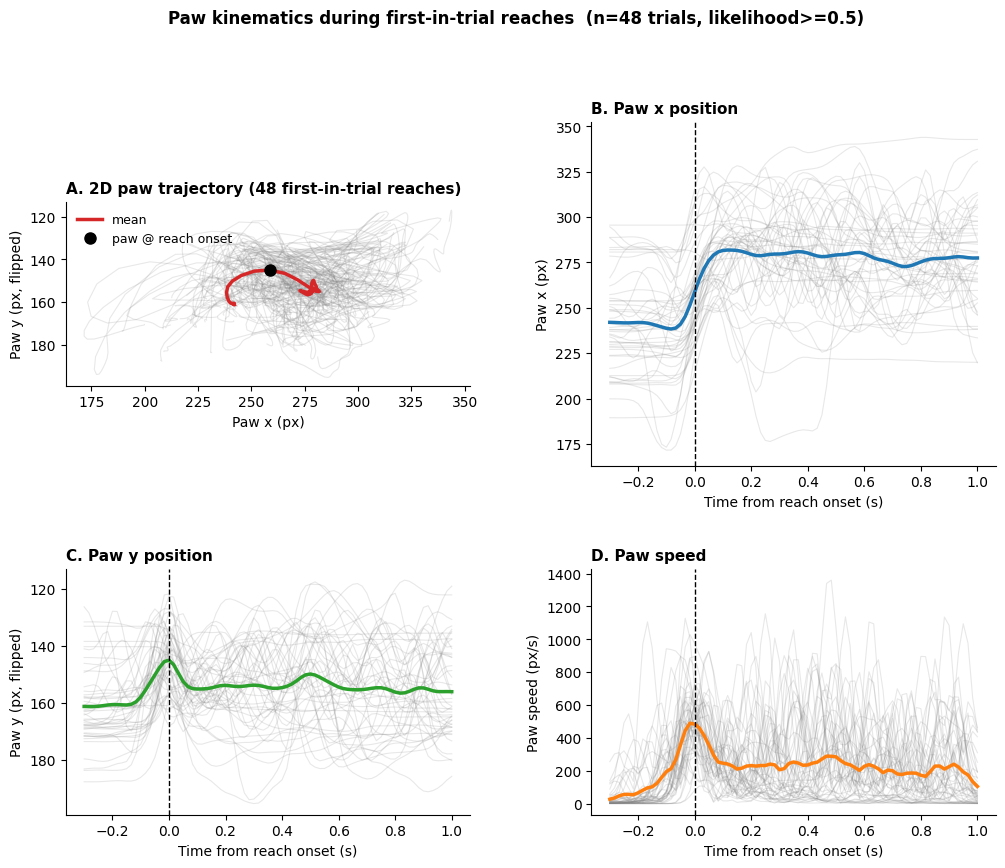


Saved -> DLC_first_reach_trajectories.png / .pdf

===== DONE =====



In [1]:
# ============================================================
# DLC REACH TRAJECTORY — FIRST IN-TRIAL REACHES (03/04)
# ============================================================
# Loads DLC paw kinematics, aligns to first-in-trial reach onsets,
# and plots:
#   A) 2D (x, y) paw trajectory spaghetti
#   B) x position vs time
#   C) y position vs time
#   D) paw speed vs time
# Uses canonical_time for drop-robust frame->second alignment.
# ============================================================
import json
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from pathlib import Path
from scipy.ndimage import gaussian_filter1d

print("\n===== DLC REACH TRAJECTORY (first in-trial reaches) =====")

# ------------------------------------------------------------
# USER EDIT
# ------------------------------------------------------------
analysis_folder = Path(
    r"G:\Kevin\2026-03-09_14-29-25\Record Node 114\2026-03-09_14-29-25_experiment2_recording1_analysis"
)
dlc_npz_path = Path(
    r"G:\Kevin\2026-03-09_14-29-25\Record Node 114\2026-03-09_14-29-25_experiment2_recording1_analysis\dlc_alignment\full_session_dlc.npz" # update to the actual path on G drive
)

PRIMARY_BODYPART  = "paw"
LIKELIHOOD_THRESH = 0.5
WIN_PRE_S         = 0.3       # seconds before reach onset
WIN_POST_S        = 1.0       # seconds after reach onset
SMOOTH_SIGMA      = 1.5       # gaussian smoothing on position (in frames; ~25 ms at 60 Hz)
FRAME_RATE        = 60.0
# ------------------------------------------------------------

# ------------------------------------------------------------
# LOAD DATA
# ------------------------------------------------------------
dlc = np.load(dlc_npz_path, allow_pickle=True)
ct = dlc["canonical_time"]            # (n_frames,)  seconds
px = dlc[f"{PRIMARY_BODYPART}_x"].astype(np.float64)
py = dlc[f"{PRIMARY_BODYPART}_y"].astype(np.float64)
pl = dlc[f"{PRIMARY_BODYPART}_likelihood"]

n_frames = len(ct)
print(f"DLC frames: {n_frames}")
print(f"Canonical time range: {ct[0]:.2f} - {ct[-1]:.2f} s")
print(f"Bodypart: {PRIMARY_BODYPART}")
print(f"Frames above likelihood threshold ({LIKELIHOOD_THRESH}): "
      f"{(pl >= LIKELIHOOD_THRESH).sum()} / {n_frames} "
      f"({100*(pl >= LIKELIHOOD_THRESH).mean():.1f}%)")

# Mask low-likelihood frames with NaN BEFORE smoothing
px_masked = np.where(pl >= LIKELIHOOD_THRESH, px, np.nan)
py_masked = np.where(pl >= LIKELIHOOD_THRESH, py, np.nan)

# Smooth (mild) — using gaussian_filter1d with nan-preserving via fill+filter trick
# Actually we'll smooth per-trial below to avoid contaminating across reach boundaries.

# ------------------------------------------------------------
# LOAD REACH EVENTS (first in-trial reaches)
# ------------------------------------------------------------
bouts = np.load(analysis_folder / "peak_detection" / "bouts.npz")
onset_t = bouts["onset_t"]
trial_id = bouts["trial_id"]

first_idx = []
for tid in sorted(set(trial_id[trial_id >= 0])):
    ii = np.where(trial_id == tid)[0]
    first_idx.append(ii[np.argmin(onset_t[ii])])
first_reach_t = np.sort(onset_t[np.array(first_idx)])
print(f"First-in-trial reaches: {len(first_reach_t)}")

# ------------------------------------------------------------
# EXTRACT PER-TRIAL TRAJECTORIES (aligned via canonical_time)
# ------------------------------------------------------------
# Build a regular time axis at 60 Hz spanning the window
window_dt = 1.0 / FRAME_RATE
window_times = np.arange(-WIN_PRE_S, WIN_POST_S + window_dt/2, window_dt)
n_bins = len(window_times)

trial_x = np.full((len(first_reach_t), n_bins), np.nan)
trial_y = np.full((len(first_reach_t), n_bins), np.nan)

kept_trials = 0
for ti, t_reach in enumerate(first_reach_t):
    # Find DLC frame closest to reach onset
    onset_frame = np.searchsorted(ct, t_reach)
    # Find window bounds
    t_lo = t_reach - WIN_PRE_S
    t_hi = t_reach + WIN_POST_S
    f_lo = np.searchsorted(ct, t_lo)
    f_hi = np.searchsorted(ct, t_hi)
    if f_hi - f_lo < 5:
        continue  # skip trials with too few frames (dropped chunk?)

    # Resample to regular grid using nearest-frame lookup
    target_times = t_reach + window_times
    target_frames = np.searchsorted(ct, target_times)
    target_frames = np.clip(target_frames, 0, n_frames - 1)
    # If any target time is more than 2 frame periods off from its assigned frame, mark NaN
    actual_times = ct[target_frames]
    bad = np.abs(actual_times - target_times) > 2 * window_dt
    tx = px_masked[target_frames].copy()
    ty = py_masked[target_frames].copy()
    tx[bad] = np.nan; ty[bad] = np.nan

    # Light smoothing per-trial (skip if too few valid frames)
    n_valid = np.sum(~np.isnan(tx))
    if n_valid >= 5:
        # Use a simple fill-then-smooth pattern for nans
        for arr in (tx, ty):
            mask = ~np.isnan(arr)
            if mask.sum() >= 3:
                idx = np.where(mask)[0]
                arr[~mask] = np.interp(np.where(~mask)[0], idx, arr[mask])
        tx = gaussian_filter1d(tx, sigma=SMOOTH_SIGMA)
        ty = gaussian_filter1d(ty, sigma=SMOOTH_SIGMA)

    trial_x[ti] = tx
    trial_y[ti] = ty
    kept_trials += 1

print(f"Kept trials: {kept_trials} / {len(first_reach_t)}")

# Compute speed: |d/dt of position|, smoothed
trial_speed = np.full_like(trial_x, np.nan)
for ti in range(len(first_reach_t)):
    dx = np.gradient(trial_x[ti]) * FRAME_RATE
    dy = np.gradient(trial_y[ti]) * FRAME_RATE
    trial_speed[ti] = np.sqrt(dx**2 + dy**2)

# Means (ignoring NaN)
mean_x = np.nanmean(trial_x, axis=0)
mean_y = np.nanmean(trial_y, axis=0)
mean_speed = np.nanmean(trial_speed, axis=0)

# Identify the time-zero index for plotting paw-at-onset
t_zero_idx = np.argmin(np.abs(window_times))

# ------------------------------------------------------------
# FIGURE
# ------------------------------------------------------------
fig = plt.figure(figsize=(12, 9))
gs = GridSpec(2, 2, height_ratios=[1.4, 1.0], width_ratios=[1, 1],
              hspace=0.35, wspace=0.30)

# ---- Panel A: 2D trajectory ----
ax = fig.add_subplot(gs[0, 0])
for ti in range(len(first_reach_t)):
    ax.plot(trial_x[ti], trial_y[ti], "-", color="0.5", alpha=0.18, lw=0.8)
# Mean
ax.plot(mean_x, mean_y, "-", color="C3", lw=2.5, label="mean")
# Paw position at reach onset
ax.plot(mean_x[t_zero_idx], mean_y[t_zero_idx], "o",
        color="black", markersize=8, label="paw @ reach onset", zorder=5)
ax.invert_yaxis()  # image coord -> natural display
ax.set_xlabel("Paw x (px)")
ax.set_ylabel("Paw y (px, flipped)")
ax.set_aspect("equal")
ax.set_title(f"A. 2D paw trajectory ({kept_trials} first-in-trial reaches)",
             fontsize=11, fontweight="bold", loc="left")
ax.legend(fontsize=9, loc="best", frameon=False)
ax.spines[["top", "right"]].set_visible(False)

# ---- Panel B: x vs time ----
ax = fig.add_subplot(gs[0, 1])
for ti in range(len(first_reach_t)):
    ax.plot(window_times, trial_x[ti], "-", color="0.5", alpha=0.18, lw=0.8)
ax.plot(window_times, mean_x, "-", color="C0", lw=2.5, label="mean")
ax.axvline(0, color="black", lw=1, linestyle="--")
ax.set_xlabel("Time from reach onset (s)")
ax.set_ylabel("Paw x (px)")
ax.set_title("B. Paw x position", fontsize=11, fontweight="bold", loc="left")
ax.spines[["top", "right"]].set_visible(False)

# ---- Panel C: y vs time ----
ax = fig.add_subplot(gs[1, 0])
for ti in range(len(first_reach_t)):
    ax.plot(window_times, trial_y[ti], "-", color="0.5", alpha=0.18, lw=0.8)
ax.plot(window_times, mean_y, "-", color="C2", lw=2.5, label="mean")
ax.axvline(0, color="black", lw=1, linestyle="--")
ax.invert_yaxis()
ax.set_xlabel("Time from reach onset (s)")
ax.set_ylabel("Paw y (px, flipped)")
ax.set_title("C. Paw y position", fontsize=11, fontweight="bold", loc="left")
ax.spines[["top", "right"]].set_visible(False)

# ---- Panel D: speed vs time ----
ax = fig.add_subplot(gs[1, 1])
for ti in range(len(first_reach_t)):
    ax.plot(window_times, trial_speed[ti], "-", color="0.5", alpha=0.18, lw=0.8)
ax.plot(window_times, mean_speed, "-", color="C1", lw=2.5, label="mean")
ax.axvline(0, color="black", lw=1, linestyle="--")
ax.set_xlabel("Time from reach onset (s)")
ax.set_ylabel("Paw speed (px/s)")
ax.set_title("D. Paw speed", fontsize=11, fontweight="bold", loc="left")
ax.spines[["top", "right"]].set_visible(False)

plt.suptitle(f"Paw kinematics during first-in-trial reaches  "
             f"(n={kept_trials} trials, likelihood>={LIKELIHOOD_THRESH})",
             fontsize=12, fontweight="bold", y=1.005)

out_base = analysis_folder / "qc" / "DLC_first_reach_trajectories"
plt.savefig(f"{out_base}.png", dpi=300, bbox_inches="tight", facecolor="white")
plt.savefig(f"{out_base}.pdf", bbox_inches="tight", facecolor="white")
plt.show()
print(f"\nSaved -> {out_base.name}.png / .pdf")
print("\n===== DONE =====\n")


===== DLC REACH TRAJECTORY (variants) =====
DLC frames: 102592, canonical_time: 12.6-1945.4 s
Frames above likelihood 0.5: 100319 / 102592 (97.8%)
First-in-trial reaches: 48

Computing onset-aligned trajectories...
  kept: 48/48
Computing peak-aligned trajectories...
  kept: 48/48


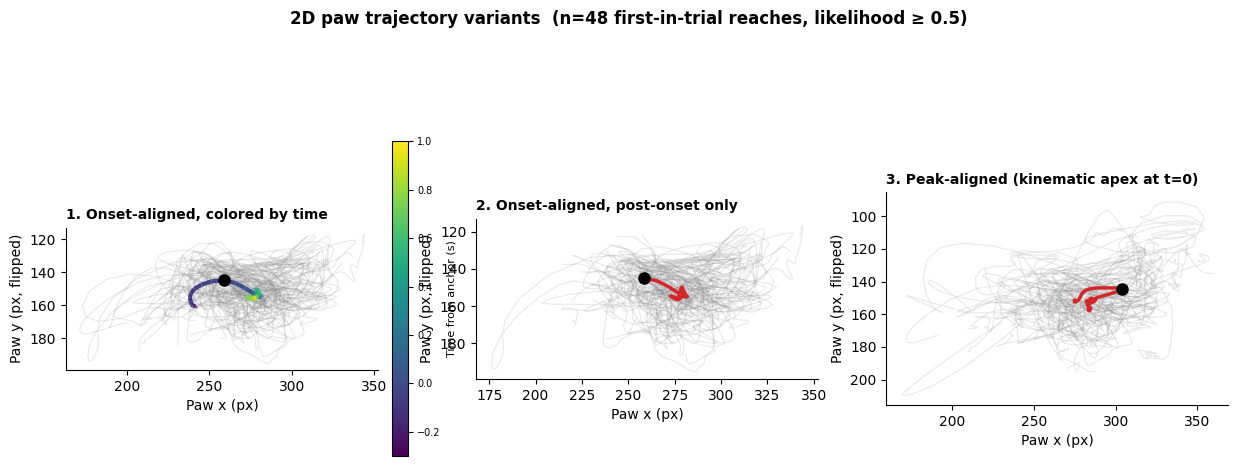


Saved -> DLC_firstreach_trajectory_variants.png / .pdf

===== DONE =====



In [4]:
# ============================================================
# DLC REACH TRAJECTORY — VARIANTS (color, post-only, peak-aligned)
# ============================================================
# Toggles:
#   - FIRST_REACH_ONLY:  True = first reach per trial; False = all in-trial reaches
#   - VARIANT:           "color_by_time" | "post_only" | "peak_aligned" | "compare"
#
# Three alignment/visualization variants for the 2D trajectory:
#   1) "color_by_time"  — onset-aligned, mean line colored by time
#   2) "post_only"      — onset-aligned, only post-onset segment shown
#   3) "peak_aligned"   — re-aligned to peak time (kinematic apex)
# Set VARIANT = "compare" to render all three side by side.
# ============================================================
import json
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.collections import LineCollection
from matplotlib.gridspec import GridSpec
from pathlib import Path
from scipy.ndimage import gaussian_filter1d

print("\n===== DLC REACH TRAJECTORY (variants) =====")

# ------------------------------------------------------------
# USER EDIT
# ------------------------------------------------------------
analysis_folder = Path(
    r"G:\Kevin\2026-03-09_14-29-25\Record Node 114\2026-03-09_14-29-25_experiment2_recording1_analysis"
)
dlc_npz_path = Path(
    r"G:\Kevin\2026-03-09_14-29-25\Record Node 114\2026-03-09_14-29-25_experiment2_recording1_analysis\dlc_alignment\full_session_dlc.npz"
)

FIRST_REACH_ONLY = True       # True: first reach per trial only; False: all in-trial reaches
VARIANT = "compare"           # "color_by_time" | "post_only" | "peak_aligned" | "compare"

PRIMARY_BODYPART  = "paw"
LIKELIHOOD_THRESH = 0.5
WIN_PRE_S         = 0.3
WIN_POST_S        = 1.0
SMOOTH_SIGMA      = 1.5
FRAME_RATE        = 60.0
# ------------------------------------------------------------

# ------------------------------------------------------------
# LOAD DLC
# ------------------------------------------------------------
dlc = np.load(dlc_npz_path, allow_pickle=True)
ct = dlc["canonical_time"]
px = dlc[f"{PRIMARY_BODYPART}_x"].astype(np.float64)
py = dlc[f"{PRIMARY_BODYPART}_y"].astype(np.float64)
pl = dlc[f"{PRIMARY_BODYPART}_likelihood"]
n_frames = len(ct)
print(f"DLC frames: {n_frames}, canonical_time: {ct[0]:.1f}-{ct[-1]:.1f} s")
print(f"Frames above likelihood {LIKELIHOOD_THRESH}: "
      f"{(pl >= LIKELIHOOD_THRESH).sum()} / {n_frames} "
      f"({100*(pl >= LIKELIHOOD_THRESH).mean():.1f}%)")

px_masked = np.where(pl >= LIKELIHOOD_THRESH, px, np.nan)
py_masked = np.where(pl >= LIKELIHOOD_THRESH, py, np.nan)

# ------------------------------------------------------------
# LOAD REACH EVENTS — filter by toggle
# ------------------------------------------------------------
bouts = np.load(analysis_folder / "peak_detection" / "bouts.npz")
onset_t_all = bouts["onset_t"]
peak_t_all  = bouts["peak_t"]
trial_id    = bouts["trial_id"]

if FIRST_REACH_ONLY:
    keep_idx = []
    for tid in sorted(set(trial_id[trial_id >= 0])):
        ii = np.where(trial_id == tid)[0]
        keep_idx.append(ii[np.argmin(onset_t_all[ii])])
    keep_idx = np.array(keep_idx)
    subset_label = "first-in-trial"
else:
    keep_idx = np.where(trial_id >= 0)[0]
    subset_label = "all in-trial"

order = np.argsort(onset_t_all[keep_idx])
keep_idx = keep_idx[order]

reach_onset_t = onset_t_all[keep_idx]
reach_peak_t  = peak_t_all[keep_idx]
print(f"{subset_label.capitalize()} reaches: {len(reach_onset_t)}")

# ------------------------------------------------------------
# EXTRACT PER-TRIAL TRAJECTORIES (helper)
# ------------------------------------------------------------
def extract_trajectories(anchor_times, win_pre, win_post):
    window_dt = 1.0 / FRAME_RATE
    window_times = np.arange(-win_pre, win_post + window_dt/2, window_dt)
    n_bins = len(window_times)
    n_trials = len(anchor_times)

    trial_x = np.full((n_trials, n_bins), np.nan)
    trial_y = np.full((n_trials, n_bins), np.nan)
    kept = 0

    for ti, t_anchor in enumerate(anchor_times):
        target_times = t_anchor + window_times
        target_frames = np.searchsorted(ct, target_times)
        target_frames = np.clip(target_frames, 0, n_frames - 1)
        actual_times = ct[target_frames]
        bad = np.abs(actual_times - target_times) > 2 * window_dt

        tx = px_masked[target_frames].copy()
        ty = py_masked[target_frames].copy()
        tx[bad] = np.nan; ty[bad] = np.nan

        n_valid = np.sum(~np.isnan(tx))
        if n_valid >= 5:
            for arr in (tx, ty):
                mask = ~np.isnan(arr)
                if mask.sum() >= 3:
                    idx = np.where(mask)[0]
                    arr[~mask] = np.interp(np.where(~mask)[0], idx, arr[mask])
            tx = gaussian_filter1d(tx, sigma=SMOOTH_SIGMA)
            ty = gaussian_filter1d(ty, sigma=SMOOTH_SIGMA)
            kept += 1
        trial_x[ti] = tx
        trial_y[ti] = ty

    trial_speed = np.full_like(trial_x, np.nan)
    for ti in range(n_trials):
        dx = np.gradient(trial_x[ti]) * FRAME_RATE
        dy = np.gradient(trial_y[ti]) * FRAME_RATE
        trial_speed[ti] = np.sqrt(dx**2 + dy**2)

    return trial_x, trial_y, trial_speed, window_times, kept

# ------------------------------------------------------------
# COMPUTE BOTH ALIGNMENT VARIANTS
# ------------------------------------------------------------
print("\nComputing onset-aligned trajectories...")
tx_on, ty_on, ts_on, wt_on, kept_on = extract_trajectories(
    reach_onset_t, WIN_PRE_S, WIN_POST_S)
print(f"  kept: {kept_on}/{len(reach_onset_t)}")

print("Computing peak-aligned trajectories...")
tx_pk, ty_pk, ts_pk, wt_pk, kept_pk = extract_trajectories(
    reach_peak_t, WIN_PRE_S, WIN_POST_S)
print(f"  kept: {kept_pk}/{len(reach_peak_t)}")

mean_x_on = np.nanmean(tx_on, axis=0)
mean_y_on = np.nanmean(ty_on, axis=0)
mean_x_pk = np.nanmean(tx_pk, axis=0)
mean_y_pk = np.nanmean(ty_pk, axis=0)

t_zero_on = np.argmin(np.abs(wt_on))
t_zero_pk = np.argmin(np.abs(wt_pk))

# ------------------------------------------------------------
# HELPER: draw a 2D trajectory panel
# ------------------------------------------------------------
def draw_2d_panel(ax, variant, trial_x, trial_y, mean_x, mean_y,
                  window_times, t_zero_idx, kept_n, title):
    if variant == "post_only":
        keep = slice(t_zero_idx, None)
        tx = trial_x[:, keep]; ty = trial_y[:, keep]
        mx = mean_x[keep]; my = mean_y[keep]
        wt = window_times[keep]
    else:
        tx, ty = trial_x, trial_y
        mx, my = mean_x, mean_y
        wt = window_times

    for ti in range(tx.shape[0]):
        ax.plot(tx[ti], ty[ti], "-", color="0.5", alpha=0.18, lw=0.8)

    if variant == "color_by_time":
        pts = np.column_stack([mx, my])
        valid = ~(np.isnan(pts[:, 0]) | np.isnan(pts[:, 1]))
        pts_v = pts[valid]; wt_v = wt[valid]
        if len(pts_v) >= 2:
            segments = np.stack([pts_v[:-1], pts_v[1:]], axis=1)
            cmap = plt.cm.viridis
            norm = mcolors.Normalize(vmin=wt_v[0], vmax=wt_v[-1])
            lc = LineCollection(segments, cmap=cmap, norm=norm,
                                linewidth=3.0, zorder=4)
            lc.set_array(wt_v[:-1])
            ax.add_collection(lc)
            cb = plt.colorbar(lc, ax=ax, fraction=0.046, pad=0.04)
            cb.set_label("Time from anchor (s)", fontsize=8)
            cb.ax.tick_params(labelsize=7)
    else:
        ax.plot(mx, my, "-", color="C3", lw=2.5, zorder=4)

    if variant == "post_only":
        if not (np.isnan(mx[0]) or np.isnan(my[0])):
            ax.plot(mx[0], my[0], "o", color="black", markersize=8, zorder=5)
    else:
        if not (np.isnan(mean_x[t_zero_idx]) or np.isnan(mean_y[t_zero_idx])):
            ax.plot(mean_x[t_zero_idx], mean_y[t_zero_idx], "o",
                    color="black", markersize=8, zorder=5)

    ax.invert_yaxis()
    ax.set_xlabel("Paw x (px)")
    ax.set_ylabel("Paw y (px, flipped)")
    ax.set_aspect("equal")
    ax.set_title(title, fontsize=10, fontweight="bold", loc="left")
    ax.spines[["top", "right"]].set_visible(False)

# ------------------------------------------------------------
# FIGURE — branches on VARIANT
# ------------------------------------------------------------
if VARIANT == "compare":
    fig, axes = plt.subplots(1, 3, figsize=(15, 5.5))
    draw_2d_panel(axes[0], "color_by_time",
                  tx_on, ty_on, mean_x_on, mean_y_on, wt_on, t_zero_on,
                  kept_on, "1. Onset-aligned, colored by time")
    draw_2d_panel(axes[1], "post_only",
                  tx_on, ty_on, mean_x_on, mean_y_on, wt_on, t_zero_on,
                  kept_on, "2. Onset-aligned, post-onset only")
    draw_2d_panel(axes[2], "peak_aligned",
                  tx_pk, ty_pk, mean_x_pk, mean_y_pk, wt_pk, t_zero_pk,
                  kept_pk, "3. Peak-aligned (kinematic apex at t=0)")

    plt.suptitle(f"2D paw trajectory variants  "
                 f"(n={kept_on} {subset_label} reaches, "
                 f"likelihood ≥ {LIKELIHOOD_THRESH})",
                 fontsize=12, fontweight="bold", y=1.02)
    fn_subset = "firstreach" if FIRST_REACH_ONLY else "allreaches"
    out_name = f"DLC_{fn_subset}_trajectory_variants"

else:
    fig = plt.figure(figsize=(12, 9))
    gs = GridSpec(2, 2, height_ratios=[1.4, 1.0], width_ratios=[1, 1],
                  hspace=0.35, wspace=0.30)

    if VARIANT == "peak_aligned":
        tx, ty, ts, wt, tz, kept_n = tx_pk, ty_pk, ts_pk, wt_pk, t_zero_pk, kept_pk
        mx, my = mean_x_pk, mean_y_pk
        anchor_label = "peak"
    else:
        tx, ty, ts, wt, tz, kept_n = tx_on, ty_on, ts_on, wt_on, t_zero_on, kept_on
        mx, my = mean_x_on, mean_y_on
        anchor_label = "onset"
    mean_speed = np.nanmean(ts, axis=0)

    ax = fig.add_subplot(gs[0, 0])
    panel_title = {
        "color_by_time": f"A. 2D trajectory, colored by time (t=0 at {anchor_label})",
        "post_only":     f"A. 2D trajectory, post-{anchor_label} only",
        "peak_aligned":  f"A. 2D trajectory, peak-aligned"
    }[VARIANT]
    draw_2d_panel(ax, VARIANT, tx, ty, mx, my, wt, tz, kept_n, panel_title)

    ax = fig.add_subplot(gs[0, 1])
    for ti in range(tx.shape[0]):
        ax.plot(wt, tx[ti], "-", color="0.5", alpha=0.18, lw=0.8)
    ax.plot(wt, mx, "-", color="C0", lw=2.5)
    ax.axvline(0, color="black", lw=1, linestyle="--")
    ax.set_xlabel(f"Time from {anchor_label} (s)")
    ax.set_ylabel("Paw x (px)")
    ax.set_title(f"B. Paw x position", fontsize=11, fontweight="bold", loc="left")
    ax.spines[["top", "right"]].set_visible(False)

    ax = fig.add_subplot(gs[1, 0])
    for ti in range(ty.shape[0]):
        ax.plot(wt, ty[ti], "-", color="0.5", alpha=0.18, lw=0.8)
    ax.plot(wt, my, "-", color="C2", lw=2.5)
    ax.axvline(0, color="black", lw=1, linestyle="--")
    ax.invert_yaxis()
    ax.set_xlabel(f"Time from {anchor_label} (s)")
    ax.set_ylabel("Paw y (px, flipped)")
    ax.set_title(f"C. Paw y position", fontsize=11, fontweight="bold", loc="left")
    ax.spines[["top", "right"]].set_visible(False)

    ax = fig.add_subplot(gs[1, 1])
    for ti in range(ts.shape[0]):
        ax.plot(wt, ts[ti], "-", color="0.5", alpha=0.18, lw=0.8)
    ax.plot(wt, mean_speed, "-", color="C1", lw=2.5)
    ax.axvline(0, color="black", lw=1, linestyle="--")
    ax.set_xlabel(f"Time from {anchor_label} (s)")
    ax.set_ylabel("Paw speed (px/s)")
    ax.set_title(f"D. Paw speed", fontsize=11, fontweight="bold", loc="left")
    ax.spines[["top", "right"]].set_visible(False)

    plt.suptitle(f"Paw kinematics during {subset_label} reaches  "
                 f"(n={kept_n}, variant={VARIANT}, "
                 f"likelihood ≥ {LIKELIHOOD_THRESH})",
                 fontsize=12, fontweight="bold", y=1.005)
    fn_subset = "firstreach" if FIRST_REACH_ONLY else "allreaches"
    out_name = f"DLC_{fn_subset}_trajectories_{VARIANT}"

out_base = analysis_folder / "qc" / out_name
plt.savefig(f"{out_base}.png", dpi=300, bbox_inches="tight", facecolor="white")
plt.savefig(f"{out_base}.pdf", bbox_inches="tight", facecolor="white")
plt.show()
print(f"\nSaved -> {out_base.name}.png / .pdf")
print("\n===== DONE =====\n")


===== REACH COMPETENCE PROFILE =====

--- Novice ---
  trials with reaches: 48
  total reaches:       48
  variability (px):    median 31.1
  path length (px):    median 133.3
  peak speed (px/s):   median 666.9
  time-to-peak (s):    median 0.158
  reaches/trial:       1.67

--- Trained ---
  trials with reaches: 48
  total reaches:       48
  variability (px):    median 22.0
  path length (px):    median 260.7
  peak speed (px/s):   median 736.9
  time-to-peak (s):    median 0.350
  reaches/trial:       2.48

--- Mann-Whitney U tests (per metric, between sessions) ---
  Variability       : U=1543, p=0.00422  (Novice median=31.11 vs Trained median=21.97)
  Path length       : U=706, p=0.0011  (Novice median=133.33 vs Trained median=260.68)
  Peak speed        : U=1006, p=0.286  (Novice median=666.92 vs Trained median=736.87)
  Time-to-peak      : U=916, p=0.0828  (Novice median=0.16 vs Trained median=0.35)


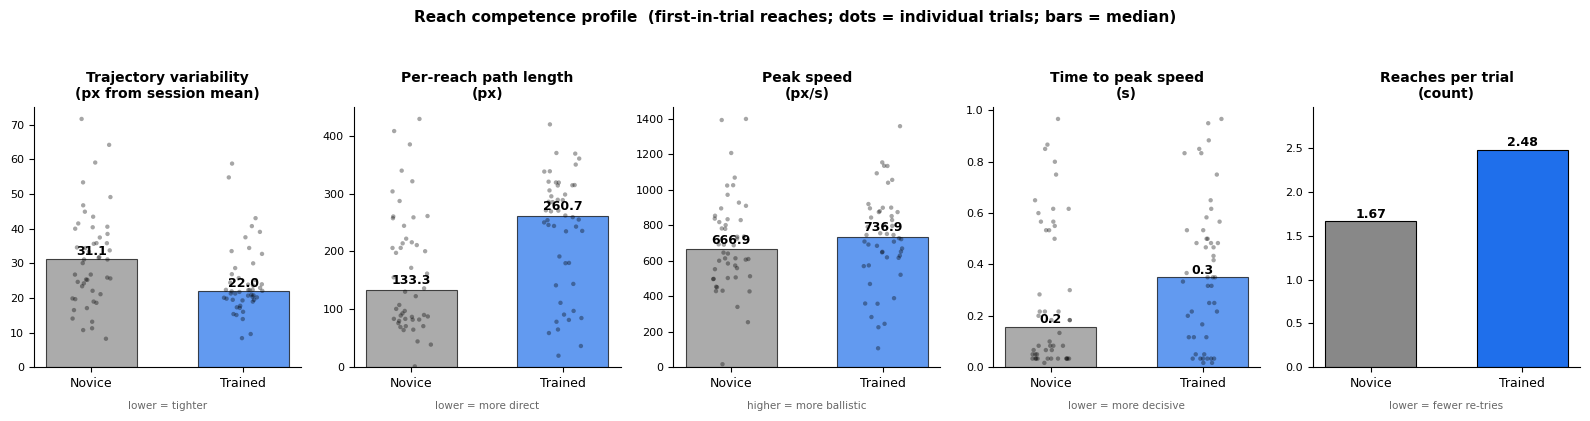


Saved -> DLC_reach_competence_firstreach.png / .pdf

===== DONE =====



In [5]:
# ============================================================
# REACH COMPETENCE PROFILE — TWO-SESSION COMPARISON
# ============================================================
# Computes five kinematic metrics per session and plots them
# side-by-side as a comparison bar grid:
#   1) Trajectory variability (mean per-trial deviation from session mean)
#   2) Mean per-reach path length (px)
#   3) Mean peak speed (px/s)
#   4) Mean time-to-peak speed (s)
#   5) Mean reaches per trial
#
# Per-trial values within each session are also shown as individual
# dots overlaid on the bars (showing trial-to-trial spread).
# Per-metric Mann-Whitney U test between sessions printed to console.
# ============================================================
import json
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from pathlib import Path
from scipy.ndimage import gaussian_filter1d
from scipy.stats import mannwhitneyu

print("\n===== REACH COMPETENCE PROFILE =====")

# ------------------------------------------------------------
# USER EDIT — two sessions to compare
# ------------------------------------------------------------
SESSIONS = [
    {
        "label": "Novice",
        "analysis_folder": Path(
            r"G:\Kevin\2026-03-04_08-31-33\Record Node 101\2026-03-04_08-31-33_experiment1_recording1_analysis"
        ),
        "dlc_npz_path": Path(
            r"G:\Kevin\2026-03-04_08-31-33\Record Node 101\2026-03-04_08-31-33_experiment1_recording1_analysis\dlc_alignment\full_session_dlc.npz"
        ),
        "color": "#888888",   # gray for novice
    },
    {
        "label": "Trained",
        "analysis_folder": Path(
            r"G:\Kevin\2026-03-09_14-29-25\Record Node 114\2026-03-09_14-29-25_experiment2_recording1_analysis"
        ),
        "dlc_npz_path": Path(
            r"G:\Kevin\2026-03-09_14-29-25\Record Node 114\2026-03-09_14-29-25_experiment2_recording1_analysis\dlc_alignment\full_session_dlc.npz"
        ),
        "color": "#1f6feb",   # blue for trained
    },
]

FIRST_REACH_ONLY  = True    # match other DLC cells
PRIMARY_BODYPART  = "paw"
LIKELIHOOD_THRESH = 0.5
WIN_PRE_S         = 0.0      # competence metrics use post-onset window only
WIN_POST_S        = 1.0
SMOOTH_SIGMA      = 1.5
FRAME_RATE        = 60.0

OUTPUT_FOLDER = Path(r"G:\Kevin\unit_matching")
# ------------------------------------------------------------

# ------------------------------------------------------------
# HELPER: load one session and compute per-trial metrics
# ------------------------------------------------------------
def compute_session_metrics(session):
    dlc = np.load(session["dlc_npz_path"], allow_pickle=True)
    ct = dlc["canonical_time"]
    px = dlc[f"{PRIMARY_BODYPART}_x"].astype(np.float64)
    py = dlc[f"{PRIMARY_BODYPART}_y"].astype(np.float64)
    pl = dlc[f"{PRIMARY_BODYPART}_likelihood"]
    n_frames = len(ct)
    px_m = np.where(pl >= LIKELIHOOD_THRESH, px, np.nan)
    py_m = np.where(pl >= LIKELIHOOD_THRESH, py, np.nan)

    bouts = np.load(session["analysis_folder"] / "peak_detection" / "bouts.npz")
    onset_t_all = bouts["onset_t"]
    trial_id    = bouts["trial_id"]

    if FIRST_REACH_ONLY:
        idx = [np.where(trial_id == tid)[0][np.argmin(onset_t_all[np.where(trial_id == tid)[0]])]
               for tid in sorted(set(trial_id[trial_id >= 0]))]
        idx = np.array(idx)
    else:
        idx = np.where(trial_id >= 0)[0]
    reach_onset_t = np.sort(onset_t_all[idx])

    # ---- extract trajectories ----
    window_dt = 1.0 / FRAME_RATE
    window_times = np.arange(-WIN_PRE_S, WIN_POST_S + window_dt/2, window_dt)
    n_bins = len(window_times)
    n_trials = len(reach_onset_t)
    trial_x = np.full((n_trials, n_bins), np.nan)
    trial_y = np.full((n_trials, n_bins), np.nan)

    for ti, t_anchor in enumerate(reach_onset_t):
        target_times = t_anchor + window_times
        target_frames = np.searchsorted(ct, target_times)
        target_frames = np.clip(target_frames, 0, n_frames - 1)
        bad = np.abs(ct[target_frames] - target_times) > 2 * window_dt
        tx = px_m[target_frames].copy(); ty = py_m[target_frames].copy()
        tx[bad] = np.nan; ty[bad] = np.nan
        if np.sum(~np.isnan(tx)) >= 5:
            for arr in (tx, ty):
                m = ~np.isnan(arr)
                if m.sum() >= 3:
                    arr[~m] = np.interp(np.where(~m)[0],
                                        np.where(m)[0], arr[m])
            tx = gaussian_filter1d(tx, sigma=SMOOTH_SIGMA)
            ty = gaussian_filter1d(ty, sigma=SMOOTH_SIGMA)
        trial_x[ti] = tx; trial_y[ti] = ty

    # speeds
    trial_speed = np.full_like(trial_x, np.nan)
    for ti in range(n_trials):
        dx = np.gradient(trial_x[ti]) * FRAME_RATE
        dy = np.gradient(trial_y[ti]) * FRAME_RATE
        trial_speed[ti] = np.sqrt(dx**2 + dy**2)

    mean_x = np.nanmean(trial_x, axis=0)
    mean_y = np.nanmean(trial_y, axis=0)

    # ---- per-trial metrics ----
    # 1) trajectory variability: mean per-frame distance from mean trajectory
    per_trial_var = np.full(n_trials, np.nan)
    for ti in range(n_trials):
        dx = trial_x[ti] - mean_x
        dy = trial_y[ti] - mean_y
        d = np.sqrt(dx**2 + dy**2)
        per_trial_var[ti] = np.nanmean(d)

    # 2) per-trial path length
    path_length = np.full(n_trials, np.nan)
    for ti in range(n_trials):
        dx = np.diff(trial_x[ti])
        dy = np.diff(trial_y[ti])
        step = np.sqrt(dx**2 + dy**2)
        path_length[ti] = np.nansum(step)

    # 3) peak speed per trial
    peak_speed = np.full(n_trials, np.nan)
    # 4) time-to-peak speed
    time_to_peak = np.full(n_trials, np.nan)
    for ti in range(n_trials):
        sp = trial_speed[ti]
        if np.all(np.isnan(sp)):
            continue
        valid = ~np.isnan(sp)
        if valid.sum() < 3:
            continue
        peak_idx = int(np.nanargmax(sp))
        peak_speed[ti] = sp[peak_idx]
        time_to_peak[ti] = window_times[peak_idx]

    # 5) reaches per trial (a per-trial count, not per-reach)
    n_trial_ids = len(set(trial_id[trial_id >= 0]))
    n_in_trial_reaches = int(np.sum(trial_id >= 0))
    reaches_per_trial = n_in_trial_reaches / max(n_trial_ids, 1)

    return {
        "label": session["label"],
        "color": session["color"],
        "n_trials": n_trials,
        "n_trial_ids": n_trial_ids,
        "trajectory_variability": per_trial_var[~np.isnan(per_trial_var)],
        "path_length":            path_length[~np.isnan(path_length)],
        "peak_speed":             peak_speed[~np.isnan(peak_speed)],
        "time_to_peak":           time_to_peak[~np.isnan(time_to_peak)],
        "reaches_per_trial":      reaches_per_trial,
    }

# ------------------------------------------------------------
# COMPUTE
# ------------------------------------------------------------
results = [compute_session_metrics(s) for s in SESSIONS]
for r in results:
    print(f"\n--- {r['label']} ---")
    print(f"  trials with reaches: {r['n_trial_ids']}")
    print(f"  total reaches:       {r['n_trials']}")
    print(f"  variability (px):    median {np.median(r['trajectory_variability']):.1f}")
    print(f"  path length (px):    median {np.median(r['path_length']):.1f}")
    print(f"  peak speed (px/s):   median {np.median(r['peak_speed']):.1f}")
    print(f"  time-to-peak (s):    median {np.median(r['time_to_peak']):.3f}")
    print(f"  reaches/trial:       {r['reaches_per_trial']:.2f}")

# ------------------------------------------------------------
# STATISTICS — Mann-Whitney U between sessions per metric
# ------------------------------------------------------------
print("\n--- Mann-Whitney U tests (per metric, between sessions) ---")
for key, label in [("trajectory_variability", "Variability"),
                    ("path_length",            "Path length"),
                    ("peak_speed",             "Peak speed"),
                    ("time_to_peak",           "Time-to-peak")]:
    a = results[0][key]; b = results[1][key]
    if len(a) >= 3 and len(b) >= 3:
        u, p = mannwhitneyu(a, b, alternative="two-sided")
        print(f"  {label:<18}: U={u:.0f}, p={p:.3g}  "
              f"({results[0]['label']} median={np.median(a):.2f} vs "
              f"{results[1]['label']} median={np.median(b):.2f})")

# ------------------------------------------------------------
# FIGURE — 5-panel comparison
# ------------------------------------------------------------
fig, axes = plt.subplots(1, 5, figsize=(16, 4))

panel_defs = [
    ("trajectory_variability", "Trajectory variability\n(px from session mean)",
     "lower = tighter"),
    ("path_length",            "Per-reach path length\n(px)",
     "lower = more direct"),
    ("peak_speed",             "Peak speed\n(px/s)",
     "higher = more ballistic"),
    ("time_to_peak",           "Time to peak speed\n(s)",
     "lower = more decisive"),
    ("reaches_per_trial",      "Reaches per trial\n(count)",
     "lower = fewer re-tries"),
]

for ax, (key, title, hint) in zip(axes, panel_defs):
    if key == "reaches_per_trial":
        vals = [r[key] for r in results]
        xs = np.arange(len(results))
        bars = ax.bar(xs, vals,
                      color=[r["color"] for r in results],
                      edgecolor="black", linewidth=0.8, width=0.6)
        for b, v in zip(bars, vals):
            ax.text(b.get_x() + b.get_width()/2, v * 1.02,
                    f"{v:.2f}", ha="center", fontsize=9, fontweight="bold")
        ax.set_ylim(0, max(vals) * 1.2)
    else:
        data = [r[key] for r in results]
        medians = [np.median(d) for d in data]
        xs = np.arange(len(results))
        bars = ax.bar(xs, medians,
                      color=[r["color"] for r in results],
                      edgecolor="black", linewidth=0.8, width=0.6,
                      alpha=0.7)
        # overlay individual points
        for xi, (vals, color) in enumerate(zip(data, [r["color"] for r in results])):
            jitter = np.random.uniform(-0.13, 0.13, size=len(vals))
            ax.scatter(np.full_like(vals, xi) + jitter, vals,
                       s=10, color="black", alpha=0.35, edgecolor="none",
                       zorder=3)
        for b, m in zip(bars, medians):
            ax.text(b.get_x() + b.get_width()/2, m + (max(medians) * 0.04),
                    f"{m:.1f}", ha="center", fontsize=9, fontweight="bold")

    ax.set_xticks(xs)
    ax.set_xticklabels([r["label"] for r in results], fontsize=9)
    ax.set_title(title, fontsize=10, fontweight="bold")
    ax.set_xlabel(hint, fontsize=7.5, color="0.4", labelpad=8)
    ax.spines[["top", "right"]].set_visible(False)
    ax.tick_params(axis="y", labelsize=8)

plt.suptitle(f"Reach competence profile  "
             f"({'first-in-trial' if FIRST_REACH_ONLY else 'all in-trial'} reaches; "
             f"dots = individual trials; bars = median)",
             fontsize=11, fontweight="bold", y=1.04)
plt.tight_layout()

fn_subset = "firstreach" if FIRST_REACH_ONLY else "allreaches"
out_base = OUTPUT_FOLDER / f"DLC_reach_competence_{fn_subset}"
plt.savefig(f"{out_base}.png", dpi=300, bbox_inches="tight", facecolor="white")
plt.savefig(f"{out_base}.pdf", bbox_inches="tight", facecolor="white")
plt.show()
print(f"\nSaved -> {out_base.name}.png / .pdf")
print("\n===== DONE =====\n")


===== DLC REACH TRAJECTORY — TWO-SESSION COMPARISON =====

Loading Novice...
  48 trials extracted

Loading Trained...
  48 trials extracted


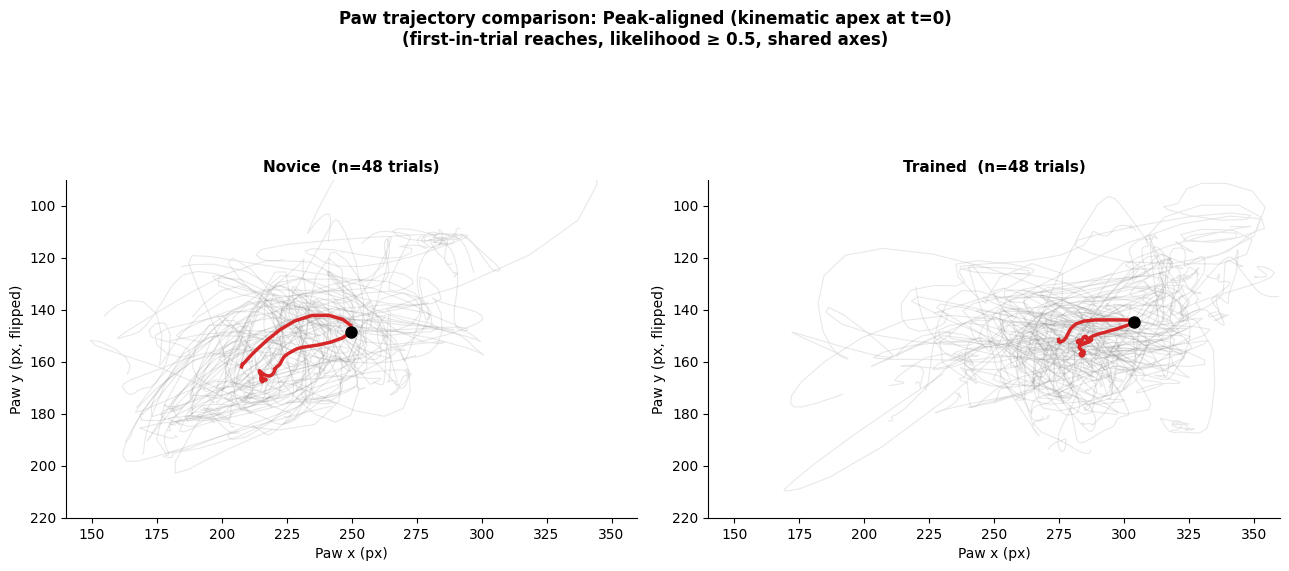


Saved -> DLC_compare_Novice_vs_Trained_firstreach_peak_aligned.png / .pdf

===== DONE =====



In [6]:
# ============================================================
# DLC REACH TRAJECTORY — TWO-SESSION COMPARISON (shared axes)
# ============================================================
# Plots one trajectory panel per session, side by side, with
# identical x/y limits so they're directly comparable.
#
# Toggles:
#   - VARIANT: "color_by_time" | "post_only" | "peak_aligned"
#   - FIRST_REACH_ONLY: True (first per trial) or False (all in-trial)
# ============================================================
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.collections import LineCollection
from pathlib import Path
from scipy.ndimage import gaussian_filter1d

print("\n===== DLC REACH TRAJECTORY — TWO-SESSION COMPARISON =====")

# ------------------------------------------------------------
# USER EDIT
# ------------------------------------------------------------
SESSIONS = [
    {
        "label": "Novice",
        "analysis_folder": Path(
            r"G:\Kevin\2026-03-04_08-31-33\Record Node 101\2026-03-04_08-31-33_experiment1_recording1_analysis"
        ),
        "dlc_npz_path": Path(
            r"G:\Kevin\2026-03-04_08-31-33\Record Node 101\2026-03-04_08-31-33_experiment1_recording1_analysis\dlc_alignment\full_session_dlc.npz"
        ),
    },
    {
        "label": "Trained",
        "analysis_folder": Path(
            r"G:\Kevin\2026-03-09_14-29-25\Record Node 114\2026-03-09_14-29-25_experiment2_recording1_analysis"
        ),
        "dlc_npz_path": Path(
            r"G:\Kevin\2026-03-09_14-29-25\Record Node 114\2026-03-09_14-29-25_experiment2_recording1_analysis\dlc_alignment\full_session_dlc.npz"
        ),
    },
]

VARIANT          = "peak_aligned"   # "color_by_time" | "post_only" | "peak_aligned"
FIRST_REACH_ONLY = True

# Hardcoded shared axes (px). Set to None to auto-fit to data.
FIXED_XLIM = (140, 360)
FIXED_YLIM = (90,  220)   # raw y; will be inverted on display

PRIMARY_BODYPART  = "paw"
LIKELIHOOD_THRESH = 0.5
WIN_PRE_S         = 0.3
WIN_POST_S        = 1.0
SMOOTH_SIGMA      = 1.5
FRAME_RATE        = 60.0

OUTPUT_FOLDER = Path(r"G:\Kevin\unit_matching")
# ------------------------------------------------------------

# ------------------------------------------------------------
# HELPER: load one session and extract per-trial trajectories
# ------------------------------------------------------------
def load_session_trajectories(session):
    dlc = np.load(session["dlc_npz_path"], allow_pickle=True)
    ct = dlc["canonical_time"]
    px = dlc[f"{PRIMARY_BODYPART}_x"].astype(np.float64)
    py = dlc[f"{PRIMARY_BODYPART}_y"].astype(np.float64)
    pl = dlc[f"{PRIMARY_BODYPART}_likelihood"]
    n_frames = len(ct)
    px_m = np.where(pl >= LIKELIHOOD_THRESH, px, np.nan)
    py_m = np.where(pl >= LIKELIHOOD_THRESH, py, np.nan)

    bouts = np.load(session["analysis_folder"] / "peak_detection" / "bouts.npz")
    onset_t_all = bouts["onset_t"]
    peak_t_all  = bouts["peak_t"]
    trial_id    = bouts["trial_id"]

    if FIRST_REACH_ONLY:
        keep_idx = []
        for tid in sorted(set(trial_id[trial_id >= 0])):
            ii = np.where(trial_id == tid)[0]
            keep_idx.append(ii[np.argmin(onset_t_all[ii])])
        keep_idx = np.array(keep_idx)
    else:
        keep_idx = np.where(trial_id >= 0)[0]
    order = np.argsort(onset_t_all[keep_idx])
    keep_idx = keep_idx[order]

    onset_times = onset_t_all[keep_idx]
    peak_times  = peak_t_all[keep_idx]

    # Choose anchor based on variant
    if VARIANT == "peak_aligned":
        anchors = peak_times
    else:
        anchors = onset_times

    window_dt = 1.0 / FRAME_RATE
    window_times = np.arange(-WIN_PRE_S, WIN_POST_S + window_dt/2, window_dt)
    n_bins = len(window_times)
    n_trials = len(anchors)

    trial_x = np.full((n_trials, n_bins), np.nan)
    trial_y = np.full((n_trials, n_bins), np.nan)

    for ti, t_anchor in enumerate(anchors):
        target_times = t_anchor + window_times
        target_frames = np.searchsorted(ct, target_times)
        target_frames = np.clip(target_frames, 0, n_frames - 1)
        bad = np.abs(ct[target_frames] - target_times) > 2 * window_dt
        tx = px_m[target_frames].copy()
        ty = py_m[target_frames].copy()
        tx[bad] = np.nan; ty[bad] = np.nan
        if np.sum(~np.isnan(tx)) >= 5:
            for arr in (tx, ty):
                m = ~np.isnan(arr)
                if m.sum() >= 3:
                    arr[~m] = np.interp(np.where(~m)[0],
                                        np.where(m)[0], arr[m])
            tx = gaussian_filter1d(tx, sigma=SMOOTH_SIGMA)
            ty = gaussian_filter1d(ty, sigma=SMOOTH_SIGMA)
        trial_x[ti] = tx
        trial_y[ti] = ty

    mean_x = np.nanmean(trial_x, axis=0)
    mean_y = np.nanmean(trial_y, axis=0)
    t_zero_idx = np.argmin(np.abs(window_times))

    return {
        "label": session["label"],
        "trial_x": trial_x,
        "trial_y": trial_y,
        "mean_x": mean_x,
        "mean_y": mean_y,
        "window_times": window_times,
        "t_zero_idx": t_zero_idx,
        "n_trials": n_trials,
    }

# ------------------------------------------------------------
# LOAD BOTH SESSIONS
# ------------------------------------------------------------
session_data = []
for s in SESSIONS:
    print(f"\nLoading {s['label']}...")
    d = load_session_trajectories(s)
    session_data.append(d)
    print(f"  {d['n_trials']} trials extracted")

# ------------------------------------------------------------
# DRAW A PANEL FOR ONE SESSION
# ------------------------------------------------------------
def draw_panel(ax, data, variant, anchor_label):
    trial_x = data["trial_x"]; trial_y = data["trial_y"]
    mean_x = data["mean_x"];   mean_y = data["mean_y"]
    wt = data["window_times"]; tz = data["t_zero_idx"]

    if variant == "post_only":
        keep = slice(tz, None)
        tx_plot = trial_x[:, keep]
        ty_plot = trial_y[:, keep]
        mx_plot = mean_x[keep]
        my_plot = mean_y[keep]
        wt_plot = wt[keep]
    else:
        tx_plot, ty_plot = trial_x, trial_y
        mx_plot, my_plot = mean_x, mean_y
        wt_plot = wt

    # Spaghetti
    for ti in range(tx_plot.shape[0]):
        ax.plot(tx_plot[ti], ty_plot[ti], "-",
                color="0.5", alpha=0.18, lw=0.8)

    # Mean
    if variant == "color_by_time":
        pts = np.column_stack([mx_plot, my_plot])
        valid = ~(np.isnan(pts[:, 0]) | np.isnan(pts[:, 1]))
        pts_v = pts[valid]; wt_v = wt_plot[valid]
        if len(pts_v) >= 2:
            segments = np.stack([pts_v[:-1], pts_v[1:]], axis=1)
            norm = mcolors.Normalize(vmin=wt_v[0], vmax=wt_v[-1])
            lc = LineCollection(segments, cmap=plt.cm.viridis, norm=norm,
                                linewidth=3.0, zorder=4)
            lc.set_array(wt_v[:-1])
            ax.add_collection(lc)
            cb = plt.colorbar(lc, ax=ax, fraction=0.046, pad=0.04)
            cb.set_label(f"Time from {anchor_label} (s)", fontsize=8)
            cb.ax.tick_params(labelsize=7)
    else:
        ax.plot(mx_plot, my_plot, "-", color="C3", lw=2.5, zorder=4)

    # Black dot at anchor (t=0)
    if variant == "post_only":
        if not (np.isnan(mx_plot[0]) or np.isnan(my_plot[0])):
            ax.plot(mx_plot[0], my_plot[0], "o", color="black",
                    markersize=8, zorder=5)
    else:
        if not (np.isnan(mean_x[tz]) or np.isnan(mean_y[tz])):
            ax.plot(mean_x[tz], mean_y[tz], "o", color="black",
                    markersize=8, zorder=5)

    ax.set_xlabel("Paw x (px)")
    ax.set_ylabel("Paw y (px, flipped)")
    ax.set_aspect("equal")
    ax.spines[["top", "right"]].set_visible(False)
    ax.set_title(f"{data['label']}  (n={data['n_trials']} trials)",
                 fontsize=11, fontweight="bold")

# ------------------------------------------------------------
# FIGURE
# ------------------------------------------------------------
anchor_label = "peak" if VARIANT == "peak_aligned" else "onset"
subset_label = "first-in-trial" if FIRST_REACH_ONLY else "all in-trial"

fig, axes = plt.subplots(1, len(session_data), figsize=(6.5 * len(session_data), 6))
if len(session_data) == 1:
    axes = [axes]

# Determine axis limits
if FIXED_XLIM is not None and FIXED_YLIM is not None:
    xlim = FIXED_XLIM
    ylim_raw = FIXED_YLIM
else:
    # auto-fit to union of both sessions' data
    all_x = np.concatenate([d["trial_x"].ravel() for d in session_data])
    all_y = np.concatenate([d["trial_y"].ravel() for d in session_data])
    all_x = all_x[~np.isnan(all_x)]
    all_y = all_y[~np.isnan(all_y)]
    pad = 30
    xlim = (all_x.min() - pad, all_x.max() + pad)
    ylim_raw = (all_y.min() - pad, all_y.max() + pad)

# Apply panels
for ax, data in zip(axes, session_data):
    draw_panel(ax, data, VARIANT, anchor_label)
    ax.set_xlim(xlim)
    ax.set_ylim(ylim_raw[1], ylim_raw[0])   # invert y for display

variant_desc = {
    "color_by_time": f"Onset-aligned, colored by time",
    "post_only":     f"Onset-aligned, post-onset only",
    "peak_aligned":  f"Peak-aligned (kinematic apex at t=0)",
}[VARIANT]

plt.suptitle(f"Paw trajectory comparison: {variant_desc}\n"
             f"({subset_label} reaches, likelihood ≥ {LIKELIHOOD_THRESH}, "
             f"shared axes)",
             fontsize=12, fontweight="bold", y=1.02)
plt.tight_layout()

fn_subset = "firstreach" if FIRST_REACH_ONLY else "allreaches"
labels_str = "_vs_".join(s["label"] for s in SESSIONS)
out_base = OUTPUT_FOLDER / f"DLC_compare_{labels_str}_{fn_subset}_{VARIANT}"
plt.savefig(f"{out_base}.png", dpi=300, bbox_inches="tight", facecolor="white")
plt.savefig(f"{out_base}.pdf", bbox_inches="tight", facecolor="white")
plt.show()
print(f"\nSaved -> {out_base.name}.png / .pdf")
print("\n===== DONE =====\n")